# Mobility & Infrastructure EDA

## Importing Libraries & Dataset

In [18]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [19]:
# mobility & infrastructure EDA
df_mi = pd.read_csv("/Users/shaabanlaila/Desktop/summer26-sustainability-of-us-cities/data/CountyHealthRankings/CountyHealth_NC_Merged.csv")
df_mi = df_mi[['Long_Commute_Driving_Alone_Raw', 'Broadband_Access_Raw','popdensity2010','mean_commutetime2000']]
print(df_mi.shape)
df_mi.head()

(74044, 4)


,Long_Commute_Driving_Alone_Raw,Broadband_Access_Raw,popdensity2010,mean_commutetime2000
0,0.421,0.908804,504.75183,26.171911
1,0.421,0.908804,1682.17050,24.806705
2,0.421,0.908804,1633.41390,25.322525
3,0.421,0.908804,1780.03250,22.965347
4,0.421,0.908804,2446.26220,26.222353


74044 rows & 4 columns in dataset

### Columns:

**Long Commute Driving Alone Raw Value:** Among workers who commute in their car alone, the percentage that commute more than 30 minutes

**Broadband Access Raw Value:** Percentage of households with broadband internet connection

**Population Density:** Population density of census tract (neighborhood/area) in 2010

**Mean Commute Time:** Average number of minutes people in that census tract spent traveling from home to work in 2000

In [20]:
df_mi.info()
df_mi.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74044 entries, 0 to 74043
Data columns (total 4 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Long_Commute_Driving_Alone_Raw  72258 non-null  float64
 1   Broadband_Access_Raw            72258 non-null  float64
 2   popdensity2010                  73638 non-null  float64
 3   mean_commutetime2000            72417 non-null  float64
dtypes: float64(4)
memory usage: 2.3 MB


,Long_Commute_Driving_Alone_Raw,Broadband_Access_Raw,popdensity2010,mean_commutetime2000
count,72258.000000,72258.000000,73638.000000,72417.000000
mean,0.366257,0.892462,5236.559403,26.946929
std,0.118070,0.046972,11701.647911,7.015295
min,0.000000,0.481383,0.000000,2.500000
25%,0.272000,0.873799,314.851992,22.034706
50%,0.373000,0.902121,2189.995350,26.164030
75%,0.455000,0.922524,5284.300925,31.048534
max,0.745000,1.000000,543333.310000,80.025421


- All variables are numeric

- Some missing values -- 1786 in Long_Commute_Driving_Alone_Raw & Broadband_Access_Raw, 406 in popdensity2010, 1627 in mean_commutetime2000

- The average tract had a long driving commute (alone) rate of 36.6%, broadband access of 89.2%, a 2010 population density of about 5,237, and an average commute time of about 27 minutes in 2000

- Population density appears highly right-skewed, since the mean is much larger than the median and the maximum is extremely high

## Visualizations

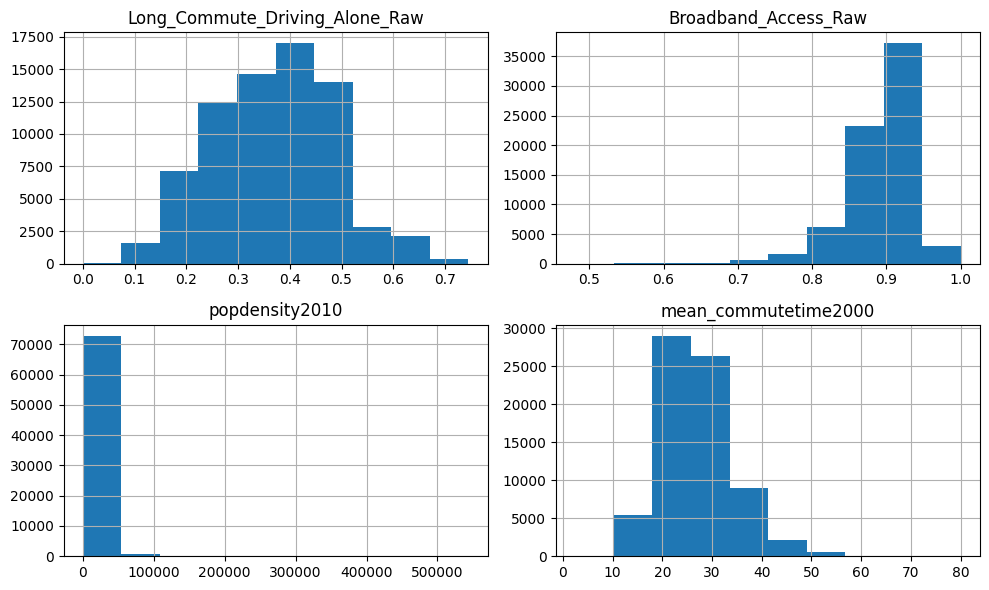

In [21]:
# histograms
df_mi.hist(figsize=(10,6))
plt.tight_layout()
plt.show()

- Long commute driving alone appears to be relatively normally distributed, although a larger portion of the data falls on the lower half of the distribution.

- Broadband access has a clear left-skew, with values centered around 0.90–0.93. This suggests that most tracts have high broadband access, with a smaller number of tracts having noticeably lower access.

- Population density in 2010 has a severe right-skew. Most census tracts have relatively low to moderate population density, while a small number of very dense tracts create extreme high-end outliers and pull the mean upward.

- Mean commute time in 2000 also has a right-skew, but it is less severe than population density. Commute times around 20–30 minutes are most common, while some tracts have much longer average commute times, reaching up to about 80 minutes.


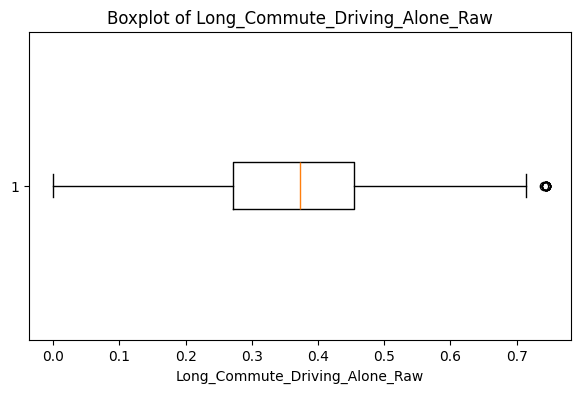

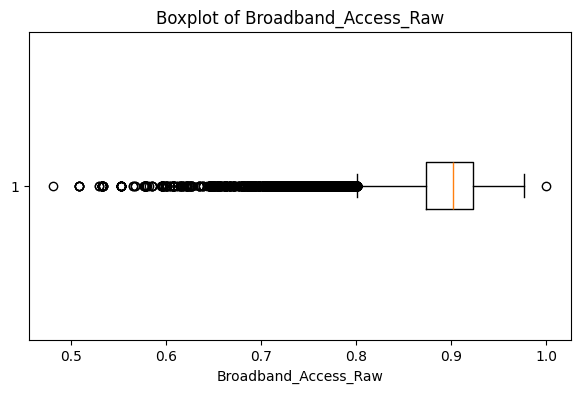

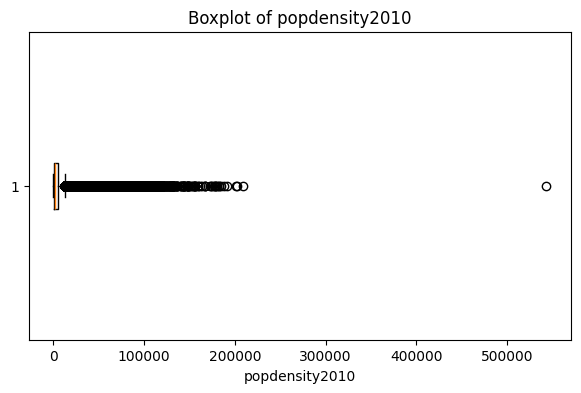

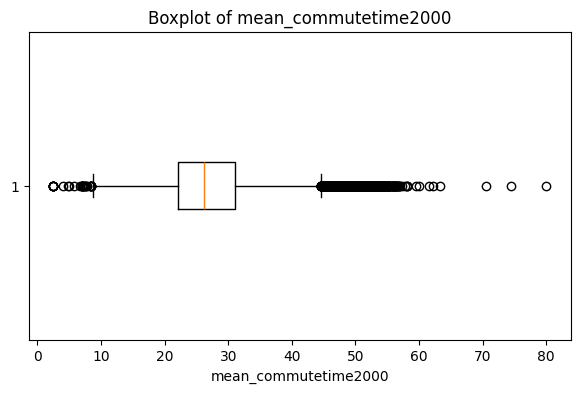

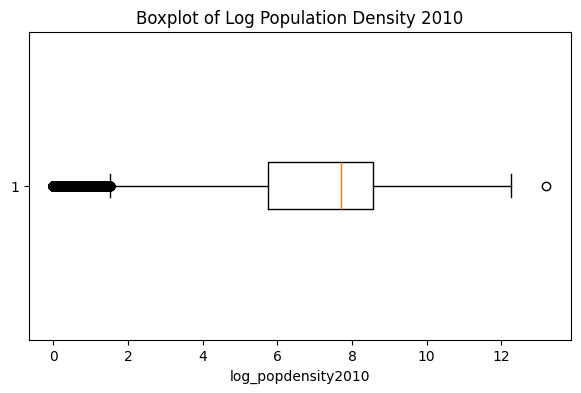

In [22]:
# boxplots
eda_cols = [
    'Long_Commute_Driving_Alone_Raw',
    'Broadband_Access_Raw',
    'popdensity2010',
    'mean_commutetime2000'
]

for col in eda_cols:
    plt.figure(figsize=(7, 4))
    plt.boxplot(df_mi[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

df_mi['log_popdensity2010'] = np.log1p(df_mi['popdensity2010']) # flattening population density's skew

plt.figure(figsize=(7, 4))
plt.boxplot(df_mi['log_popdensity2010'].dropna(), vert=False)
plt.title("Boxplot of Log Population Density 2010")
plt.xlabel("log_popdensity2010")
plt.show()

- Long commute driving alone is fairly balanced, with a few high outliers

- Broadband access is left-skewed; most tracts have high access, but some have much lower access

- Population density 2010 is extremely right-skewed with many high-density outliers

- Mean commute time 2000 is slightly/right-skewed; most commutes are around 20–30 minutes, with some much longer outliers

- **Log population density 2010 is less skewed after logging, but still has a few outliers.**


In [23]:
# checking correlation between variables
df_mi.corr()

,Long_Commute_Driving_Alone_Raw,Broadband_Access_Raw,popdensity2010,mean_commutetime2000,log_popdensity2010
Long_Commute_Driving_Alone_Raw,1.000000,0.208641,0.373843,0.713937,0.265044
Broadband_Access_Raw,0.208641,1.000000,0.092768,0.170189,0.434340
popdensity2010,0.373843,0.092768,1.000000,0.332879,0.522426
mean_commutetime2000,0.713937,0.170189,0.332879,1.000000,0.144665
log_popdensity2010,0.265044,0.434340,0.522426,0.144665,1.000000


These two variables have a strong positive correlation of 0.714, meaning that as one variable increases, the other also tends to increase. This suggests a clear linear relationship, but it does not imply causation. This may indicate possible multicollinearity if both are used in the same regression model. Since we are just doing EDA, I will leave them for now.

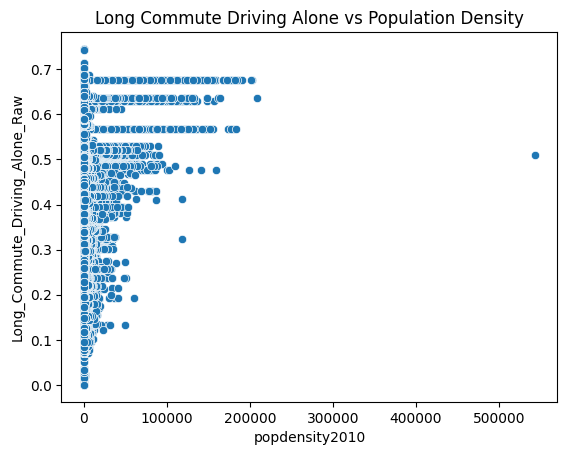

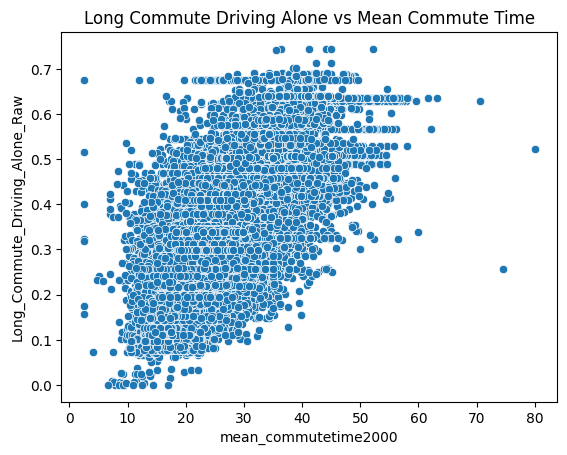

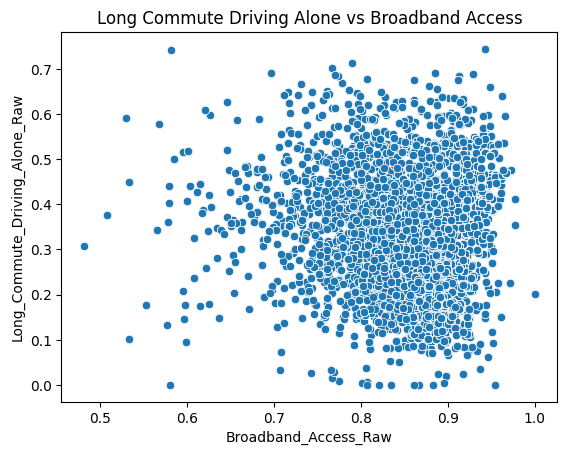

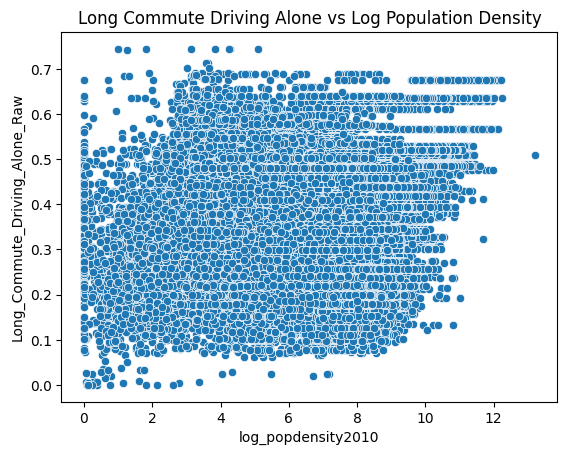

In [24]:
# scatterplots
sns.scatterplot(
    data=df_mi,
    x='popdensity2010',
    y='Long_Commute_Driving_Alone_Raw'
)
plt.title("Long Commute Driving Alone vs Population Density")
plt.show()

sns.scatterplot(
    data=df_mi,
    x='mean_commutetime2000',
    y='Long_Commute_Driving_Alone_Raw'
)
plt.title("Long Commute Driving Alone vs Mean Commute Time")
plt.show()

sns.scatterplot(
    data=df_mi,
    x='Broadband_Access_Raw',
    y='Long_Commute_Driving_Alone_Raw'
)
plt.title("Long Commute Driving Alone vs Broadband Access")
plt.show()

sns.scatterplot(
    data=df_mi,
    x='log_popdensity2010',
    y='Long_Commute_Driving_Alone_Raw'
)
plt.title("Long Commute Driving Alone vs Log Population Density")
plt.show()

- weak linear relationship between long commute driving alone vs population density

- strong linear relationship between long commute driving alone vs mean commute time in 2000

- no linear relationship between commute driving alone vs broadband access

- weak linear relationship between long commute driving alone vs population density in 2010

## Conclusions

- Most variables are numeric and mostly complete.

- Broadband access is generally high across tracts, while long commute driving alone and commute time vary more across areas.

- Population density is highly right-skewed due to a small number of very dense tracts, so a log transformation was used to make it more interpretable.

- The correlation analysis also showed one strong positive relationship, suggesting some variables may capture similar patterns across neighborhoods.